# STAT 207 — Injury Risk and Statistical Inference

**Portfolio adaptation of a group-submitted course assignment.** I independently completed the Python code, statistical analyses, visualizations, and written interpretations presented here. The original course submission listed group members; this public-facing copy does not replace the original submission.

*University of Illinois Urbana-Champaign · STAT 207*

## 1. Introduction

##### Dataset introduction

This dataset comes from "kaggle", downloaded on Feb 18, 2026, with the link https://www.kaggle.com/datasets/jayjoshi37/fifa-player-performance-and-market-value-analytics?resource=download. I downloaded it as a csv file, named "fifa_player_performance_market_value.csv". This dataset includes player demographics, position, overall rating, potential, match performance metrics (goals, assists, minutes played), contract information, and estimated market value. There are 2800 observations in total.

In [43]:
#Imports here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  

In [20]:
df = pd.read_csv("fifa_player_performance_market_value.csv")
df.head(10)

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low
5,6,Player_6,37,Argentina,Manchester City,CM,92,91,35,9,7,263,98.51,5,Yes,Low
6,7,Player_7,23,Netherlands,Liverpool,RB,72,66,53,24,6,4299,67.69,1,No,Low
7,8,Player_8,35,Spain,Bayern Munich,LW,69,97,8,34,17,3101,24.71,0,No,Low
8,9,Player_9,39,Brazil,FC Barcelona,GK,83,90,21,24,23,2106,127.50,3,Yes,High
9,10,Player_10,27,England,Liverpool,LB,69,92,0,28,5,3080,146.55,1,No,High


##### Populations and Samples

The dataset represent a sample of the professional soccer players rather than the whole entire population. And the population of interest is all the professional soccer players in the world. So that this dataset is a sample from that population.

##### Research Questions

1. What proportion of players in this dataset are injury-prone? What is a reasonable range of values for the proportion of players who are injury-prone in the population of all professional soccer players?
2. What is the average market value of players in this dataset? Is the average market value of all professional soccer players greater than 90 million euros?

##### Contextual Importance

Understanding the proportion of injury-prone players is really important, especially for teams, coaches, and managers. For example, when the coach is making decisions about player training, if a large proportion of players are injury-prone, then the coach may need to adjust their trianing pace or strategies in order to reduce the risk of getting injured, and maintain player's performance. Also, this information can help some sports organizations to better understand professional players' health trends.

Additionally, understanding player's market value can also help soccer clubs to make decisions when they are buying or selling players. For example, If the average market value is significantly different from their expectations, then the club may need to reassess their valuation strategies.

## 2. Confidence Interval Analytical Tasks

##### Research Question

What proportion of players in this dataset are injury-prone? What is a reasonable range of values for the proportion of players who are injury-prone in the population of all professional soccer players?

##### Dataset cleaning

In [21]:
df["injury_prone"].isna().sum()

np.int64(0)

In [22]:
df["injury_prone"].unique()

array(['No', 'Yes'], dtype=object)

In [29]:
df["injury_prone"] = df["injury_prone"].replace({"Yes": 1, "No": 0})

In [30]:
df["injury_prone"].unique()

array([0, 1])

In [31]:
df["injury_prone"]

0       0
1       0
2       0
3       1
4       0
       ..
2795    0
2796    0
2797    0
2798    0
2799    1
Name: injury_prone, Length: 2800, dtype: int64

In [36]:
df["injury_prone"].value_counts()

injury_prone
0    2125
1     675
Name: count, dtype: int64

I first need to check for the missing values in the variable "injury_prone", and I found there is no missing values in this variable. So that now I should convert this yes/no variable into a binary form, where “Yes” means 1 and “No” means 0. One limitation of this variable is that the definition of “injury-prone” may not capture all aspects of a player's injury history.

##### Descriptive analytics

In [34]:
df.shape

(2800, 16)

My sample size is 2800 soccer players.

In [37]:
average = df["injury_prone"].mean()
average

np.float64(0.24107142857142858)

The proportion of injury-prone players in this dataset is about 24.11%, which means about 24.11% of players in this dataset are classified as injury-prone.

##### Create a confidence interval

For this analysis, I choose a 95% confidence level.

In [59]:
data = []

for _ in range(1000):
    sample = df["injury_prone"].sample(n=2800, replace=True)
    data.append(sample.mean())

data = pd.DataFrame(data)
data

,0
0,0.242500
1,0.247857
2,0.245000
3,0.252857
4,0.245357
...,...
995,0.239286
996,0.237857
997,0.236071
998,0.241429


In [60]:
lower = data.quantile(0.025)
lower

0    0.225357
Name: 0.025, dtype: float64

In [61]:
upper = data.quantile(0.975)
upper

0    0.256429
Name: 0.975, dtype: float64

##### Interpret confidence interval

I am 95% confident that the true proportion of injury-prone players in the population of professional soccer players are between 0.225 and 0.256.

## 3. Hypothesis Testing Analytical Tasks

##### Research Question

What is the average market value of players in this dataset? Is the average market value of all professional soccer players greater than 90 million euros?

##### Dataset cleaning

In [48]:
df["market_value_million_eur"].isna().sum()

np.int64(0)

In [51]:
df["market_value_million_eur"].dtype

dtype('float64')

The variable "market_value_million_eur" has no missing values after checking by isna(). Also, I confirmed that this variable is numeric, so that no data cleaning is required. One limitation of the market value is that it may be an estimate quantity and can be influenced by many factors for example reputation.

##### Descriptive analytics

In [55]:
df["market_value_million_eur"].describe()

count    2800.000000
mean       90.565500
std        52.078881
min         0.670000
25%        45.355000
50%        89.170000
75%       136.682500
max       179.960000
Name: market_value_million_eur, dtype: float64

I can see from this data that the mean market value of players in the dataset is about 90.57 million euros, with a median of 89.17 million euros and a standard deviation of 52.08 million euros.

<Axes: >

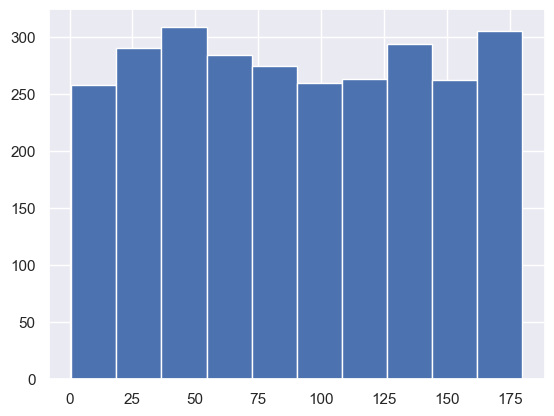

In [57]:
df["market_value_million_eur"].hist()

This is a histogram of the distribution of player's market value. I can see from this graph that the distribution is fairly spread out across all ranges of market values, and the frequencies are relatively similar, so that it is neither left skewed nor right skewed.

Since the distribution does not appear to be left or right skewed, so that the mean is an appropriate measure of center for this variable, since the mean value will take into account all the values in the dataset and can effectively summarize the overall average market value.

##### Perform a hypothesis test

Let µ be the population mean market value of all professional soccer players (measured in millions of euros). My null hypothesis is H0: µ = 90, and the alternative hypothesis is Ha: µ > 90. 

I choose to use a significance level of a = 0.05 for this hypothesis test.

My dataset will be treated as a sample from the population of all professional soccer players. And since my sample size is large, so that it supports the use of simulation inference.

In [66]:
sample_mean = df['market_value_million_eur'].mean()

shift = df['market_value_million_eur'] - sample_mean + 90

simulate_means = []

for i in range(5000):
    simulate_sample = shift.sample(n=len(shift), replace=True)
    simulate_means.append(simulate_sample.mean())

simulated_means = pd.DataFrame(simulate_means)
simulated_means

,0
0,89.839854
1,89.408200
2,88.735000
3,89.479561
4,90.882696
...,...
4995,91.303011
4996,90.580243
4997,90.545146
4998,90.944636


array([[<Axes: title={'center': '0'}>]], dtype=object)

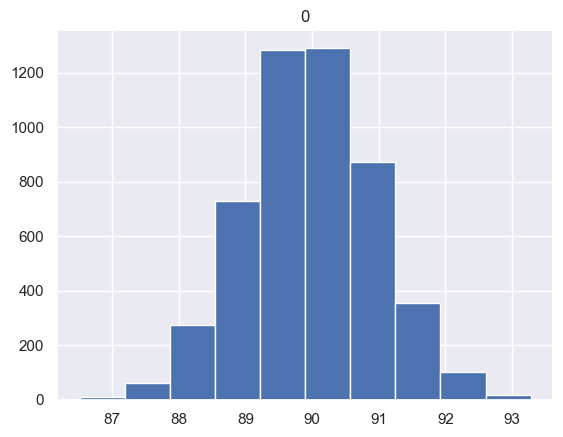

In [68]:
simulated_means.hist()

In [73]:
p_value = (simulated_means[0] >= sample_mean).mean()
p_value

np.float64(0.2712)

Since the p-value is 0.2712, which is greater than 0.05, so that I fail to reject the null hypothesis. This means I have no enough evidence to suggest that the mean market value of all professional soccer players is greater than 90 million euros.

##### Interpret p-value

If the true mean of market value of professional soccer players was 90 million euros, then the probability of getting a sample mean at least this large is 0.2712.

## 4. Conclusion

##### Summarization

The proportion of injury-prone players in this FIFA dataset is about 24.11%, which means about 24.11% of players in this dataset are classified as injury-prone. For the confidence interval analysis, I choose a 95% confidence level, and simulate 1000 times, the results shows that I are 95% confident that the true proportion of injury-prone players in the population of professional soccer players are between 0.225 and 0.256. For the hypothesis test, since the histogram of the distribution does not appear to be left or right skewed, so that the mean is an appropriate measure of center for this variable, since the mean value will take into account all the values in the dataset and can effectively summarize the overall average market value. I let µ be the population mean market value of all professional soccer players (measured in millions of euros). My null hypothesis is H0: µ = 90, and the alternative hypothesis is Ha: µ > 90. I choose to use a significance level of a = 0.05 for this hypothesis test. My dataset will be treated as a sample from the population of all professional soccer players. And since my sample size is large, so that it supports the use of simulation inference. After the hypothesis test, since the p-value is 0.2712, which is greater than 0.05, so that I fail to reject the null hypothesis. This means I have no enough evidence to suggest that the mean market value of all professional soccer players is greater than 90 million euros, and the interpretation of this p-value is if the true mean of market value of professional soccer players was 90 million euros, then the probability of getting a sample mean at least this large is 0.2712.

##### Limitations

First, the dataset does not represent all professional soccer players in the world, and it may only contains players from certain leagues or teams. Also, the assumption that the sample is representative of the population may not be so perfect, which can affect the validity of the inference, since in reality, there are a large number of professional players from low-level leagues, which means they have lower market value, so that they may lower the average market value of all population. So that only those coaches or sport team managers from larger sport teams can use this data as a reference.

##### Future work

I think future work on this dataset may explore how different factors such as age or position affect player market value.